# Cluster Revisions and Annotation

In [ ]:
import gzip as gz
import os
import tqdm
import sys

sys.path.append('./../utils')

import pandas as pd
import numpy as np
import scipy
import statsmodels
import scanpy as sc
import anndata as ad

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import sc_utils

In [ ]:
ad.__version__

In [ ]:
np.__version__

In [ ]:
pd.__version__

In [ ]:
sc.__version__

In [ ]:
pd.options.display.min_rows = 200

In [ ]:
# at some point, a package got upgraded and induced a bug in Nick's sc_util code
# here is a fixed version

def get_markers(
    anndata,
    groupby,
    key="rank_genes_groups",
    p_val_cutoff=0.05,
    logfc_cutoff=0.5
):
    markers = pd.concat([
        pd.DataFrame(anndata.uns[key]["names"]).melt(),
        pd.DataFrame(anndata.uns[key]["pvals_adj"]).melt(),
        pd.DataFrame(anndata.uns[key]["logfoldchanges"]).melt()
    ], axis=1)
    markers.columns = ("cluster", "gene", "cluster2", "p_val_adj", "cluster3", "avg_logFC")
    markers = markers.loc[:, ["cluster", "gene", "avg_logFC", "p_val_adj"]]
    markers = markers.loc[markers.avg_logFC > logfc_cutoff, ]
    markers = markers.loc[markers.p_val_adj < p_val_cutoff, ]

    for cluster in markers.cluster.unique():
        cells = anndata.obs[groupby] == cluster
        in_cluster_selector = markers.cluster == cluster
        genes = markers.gene[in_cluster_selector]
        in_cluster = np.asarray(np.sum(anndata.raw[cells, genes].X > 0, axis=0)).squeeze() / cells.sum() # linearize nx1 matrix here
        markers.loc[in_cluster_selector, "pct.1"] = in_cluster.T
        other_cells = anndata.obs[groupby] != cluster
        other_clusters = np.asarray(np.sum(anndata.raw[other_cells, genes].X > 0, axis=0)).squeeze() / other_cells.sum() # and here
        markers.loc[in_cluster_selector, "pct.2"] = other_clusters.T

    # all_clusters = markers.cluster.unique()
    # if all_clusters.size == 1:
    #     all_clusters = list(anndata.obs[groupby].astype(str).unique())
    #     if "nan" in all_clusters:
    #         all_clusters.remove("nan")
    #     all_clusters = pd.Series(all_clusters)

    markers["p_val"] = markers.p_val_adj
    markers = markers.loc[:, ["p_val", "avg_logFC", "pct.1", "pct.2", "p_val_adj", "cluster", "gene"]]
    return markers

In [ ]:
DATA_DIR = '../data/cfhv_sc'
OUT_DIR = '../data/figs/cfhv_sc'

SAMPLE_SHEET_PATH = f'{DATA_DIR}/cfhv_sc_samplesheet.csv'
sample_sheet = pd.read_csv(SAMPLE_SHEET_PATH)

In [ ]:
ds = ad.read_h5ad(f'{DATA_DIR}/cfhv_sc_raw.h5ad')

In [ ]:
ds

In [ ]:
ds.obs['Sample'] = ds.obs['Library ID']

In [ ]:
list(ds.obs['leiden'].unique())

In [ ]:
sc.pl.umap(
    ds,
    color=['leiden'],
    frameon=False,
    legend_loc="on data"
)

In [ ]:
sc.pl.umap(
    ds,
    color=['n_genes_by_counts', 'total_counts'],
    frameon=False,
    vmax='p99',
    legend_loc="on data"
)

In [ ]:
sc.pl.umap(
    ds,
    color=['Library ID', 'Class', 'Sex'],
    frameon=False,
    ncols=2
)

In [ ]:
sc.pl.umap(
    ds,
    color=['Doublet score'],
    frameon=False,
    legend_loc="on data"
)

In [ ]:
sc.pl.umap(
    ds,
    color=['CFTR'],
    frameon=False,
    legend_loc='on data'
)

## What are the clusters? What needs to be subclustered?

In [ ]:
marker_ds = ds.copy()

In [ ]:
sc.pp.normalize_total(marker_ds, target_sum=1e4)
sc.pp.log1p(marker_ds)

sc.tl.rank_genes_groups(marker_ds, 'leiden', method='wilcoxon', n_genes=200, use_raw=False)

In [ ]:
m = get_markers(marker_ds, 'leiden')

In [ ]:
m[m['cluster'] == '0'].sort_values('pct.1', ascending=False)

In [ ]:
sc.pl.umap(
    ds,
    color=['BPIFB1', 'BPIFA1', 'MUC5AC', 'PIGR', 'leiden'],
    vmax='p99',
    frameon=False,
    ncols=3
)

Ok, cluster 0 is probably secretory cells on BPIFA1, BPIFB1, MUC5AC, SCGB3A1, BPIFB2

In [ ]:
m[m['cluster'] == '1'].sort_values('pct.1', ascending=False)

In [ ]:
sc.pl.umap(
    ds,
    color=['SERPINB3', 'FABP5', 'KRT19', 'KRT10', 'leiden'],
    vmax='p99',
    frameon=False,
    ncols=3
)

Cluster 1 is maybe what we annotated as suprabasal cells before. SERPINB3, FABP5, KRT19, KRT10.
https://www.nature.com/articles/s41467-020-18075-7

In [ ]:
m[m['cluster'] == '2'].sort_values('pct.1', ascending=False)

In [ ]:
sc.pl.umap(
    ds,
    color=['KRT6A', 'KRT14', 'KRT16', 'KRT5', 'leiden'],
    vmax='p99',
    frameon=False,
    ncols=3
)

Basal cells - KRT6A, KRT14, KRT16, KRT5

In [ ]:
m[m['cluster'] == '3'].sort_values('pct.1', ascending=False)

In [ ]:
sc.pl.umap(
    ds,
    color=['C20orf85', 'C9orf24', 'CAPS'],
    vmax='p99',
    frameon=False,
    ncols=3
)

Multiciliated cells - C20orf85, C9orf24, CAPS. Probably need to subcluster, that whisp was previously low-quality cells.

In [ ]:
m[m['cluster'] == '4'].sort_values('pct.1', ascending=False)

In [ ]:
sc.pl.umap(
    ds,
    color=['PIGR', 'MUC5AC', 'SERPINB3', 'SCGB3A1', 'leiden'],
    vmax='p99',
    frameon=False,
    ncols=3
)

MUC5AC, BPIFA1 - Goblet cells - Although a subset of cluster 0 also expresses MUC5AC strongly it looks like. Maybe join cluster 4 with cluster 0?

In [ ]:
m[m['cluster'] == '5'].sort_values('pct.1', ascending=False)

In [ ]:
sc.pl.umap(
    ds,
    color=['SPRR3', 'PRSS22'],
    vmax='p99',
    frameon=False,
    ncols=3
)

Hm, not sure about these. LCN2 - epithelial AND immune cells, marker of inflammation. S100A8 predominantly neutrophils vs activated macrophages? CEACAM5 is epithelial cells, inflammation. SPRR3 differentiating keratinocytes.CEACAM5 is epithelial marker. PRSS22 is ciliated cells, SPRR3 is differentiating keratinocytes (squamous epithelium?)

Probably differentiating keratinocytes. Merge with 12?


In [ ]:
m[m['cluster'] == '6'].sort_values('pct.1', ascending=False)

Myeloid cells, needs to be subclustered

In [ ]:
m[m['cluster'] == '7'].sort_values('pct.1', ascending=False)

T-cells, NK cells? Needs to be subclustered.

In [ ]:
m[m['cluster'] == '8'].sort_values('pct.1', ascending=False)

Not sure about this, but ASCL3 is a b-cell marker. CFTR! here are our ionocytes, in here somewhere.

In [ ]:
m[m['cluster'] == '9'].sort_values('pct.1', ascending=False)

TPSAB1 and TPSB2 are mast cell markers, MS4A2 and CPA3 are mast/basophils

In [ ]:
m[m['cluster'] == '10'].sort_values('pct.1', ascending=False)

Fibroblasts vs. endothelial cells - colagens, BGN1, FN1, MMP2

In [ ]:
m[m['cluster'] == '11'].sort_values('pct.1', ascending=False)

non-keratinized stratified squamous epithelium? KRT13

In [ ]:
m[m['cluster'] == '12'].sort_values('pct.1', ascending=False)

Differentiating keratinocytes - S100A7, CNFN, CRNN. Merge into 5?

In [ ]:
m[m['cluster'] == '13'].sort_values('pct.1', ascending=False)

Stratified squamous epithelium - Merge with 11?

In [ ]:
sc.pl.rank_genes_groups_dotplot(
    marker_ds, groupby='leiden', standard_scale='var', n_genes=3
)

## Cluster To-Dos

- Add information
    - Annotation information SC174 (2020-3173-NC002 and 2020-3173-NC008)
- Join
    - Secretory cells - 0, 4 -> cluster 14
    - 5, 12 -> cluster 15 - keratinocytes?
    - Stratified squamous cells - 11, 13 -> Cluster 16
- Subcluster
    - 3 - low- quality cell whisp?
    - 6 - myeloid cells
    - 7 - t-cells, NK cells?

Name Clusters

Notes from Sasha 3/18/25:
- Keratinocytes -> Squamous per convention
- 6.1 are DC2s (CD1C+CD1E+)
- Merge 16 (stratified squamous) with 15 -> 5, 11, 12, 13 all to Cluster 15

## Add SC174 Subject Information
Recall SC174 has cells from two subjects.

* SC172 - 2020-3173-NC002
* SC173 - 2020-3173-NC008

Nick has run SoupOrCell on SC174, which will give us an idea of which subject each cell came from. Per documentation he sent, cluster 0 is SC172 (2020-3173-NC002) and cluster 1 is SC173 (2020-3173-NC008)

In [ ]:
soc_subj_ids = pd.read_csv(f'{DATA_DIR}/souporcell_045_051.tsv', sep='\t')
soc_subj_ids

In [ ]:
soc_subj_ids.groupby(['status', 'assignment']).size()

In [ ]:
soc_subj_ids['barcode_mod'] = ['CFHV_sc_subj_045+CFHV_sc_subj_051_' + bc + '-12' for bc in soc_subj_ids['barcode']]
soc_subj_ids['barcode_mod']

### Dropping non-souporcell-ed cells

Souporcell may not have been run on all cells? Will need to check, and drop cells that weren't assigned, or drop cells that were thought to be doublets.

In [ ]:
ds[ds.obs_names.str.startswith('CFHV_sc_subj_045+CFHV_sc_subj_051_')].shape

In [ ]:
soc_subj_sing_ids = soc_subj_ids[(soc_subj_ids['status'] == 'singlet')]
print(soc_subj_sing_ids.shape)

In [ ]:
ds[ds.obs_names.isin(soc_subj_sing_ids['barcode_mod'])].shape

- 3298+2665 = 5963 cells were assigned singlet by souporcell
- 6150 cells total annotated SC174, 6145 cells called by souporcell (singlet/doublet/unassigned), leaving 5 unaccounted for.
- 5956 of 6150 cells in the adata object are also annotated singlets, meaning the rest are either unannotated, or doublet/unassigned.

Not exactly sure why Nick's annotations don't cover the whole annotated data, but impact is likely minimal.

If we drop cells from the adata object that are non-singlets, we should drop 6150-5956=194 cells.

In [ ]:
print(ds.shape)

In [ ]:
ds_souporcell = ds[(~ds.obs_names.str.startswith('CFHV_sc_subj_045+CFHV_sc_subj_051')) +
                   (ds.obs_names.isin(soc_subj_sing_ids['barcode_mod']))].copy()

In [ ]:
ds_souporcell.shape

Dropped 89836-89642=194 cells.

### Assign SC172/SC173 and info

In [107]:
# Set cells that assign to cluster 0 to 045
c0_idx  = ds_souporcell.obs_names.isin(soc_subj_sing_ids[soc_subj_sing_ids['assignment'] == '0']['barcode_mod'])
ds_souporcell.obs.loc[c0_idx, 'Sample'] = 'CFHV_sc_subj_045'
ds_souporcell.obs.loc[c0_idx, 'Sex'] = 'M'

In [108]:
# Set cells that assign to cluster 0 to 051
c1_idx  = ds_souporcell.obs_names.isin(soc_subj_sing_ids[soc_subj_sing_ids['assignment'] == '1']['barcode_mod'])
ds_souporcell.obs.loc[c1_idx, 'Sample'] = 'CFHV_sc_subj_051'
ds_souporcell.obs.loc[c1_idx, 'Sex'] = 'M'

In [109]:
list(ds_souporcell.obs['Sample'].unique())

[nan, 'CFHV_sc_subj_051', 'CFHV_sc_subj_045']

### Overwrite the adata object for cluster modification/annotation

In [56]:
ds = ds_souporcell

## Annotate, Merge and Subcluster

### Setup

In [57]:
ds.obs['leiden_mod'] = ds.obs['leiden'].copy()
ds.obs['leiden_unmerged'] = ds.obs['leiden'].copy()

### Merge Clusters

#### Merge Secretory Cells

0, 4 -> 14

In [58]:
new_c = '14'
if new_c not in ds.obs['leiden_mod'].cat.categories:
    ds.obs['leiden_mod'] = ds.obs['leiden_mod'].cat.add_categories(new_c)

ds.obs.loc[ds.obs['leiden'] == '0', 'leiden_mod'] = new_c
ds.obs.loc[ds.obs['leiden'] == '4', 'leiden_mod'] = new_c

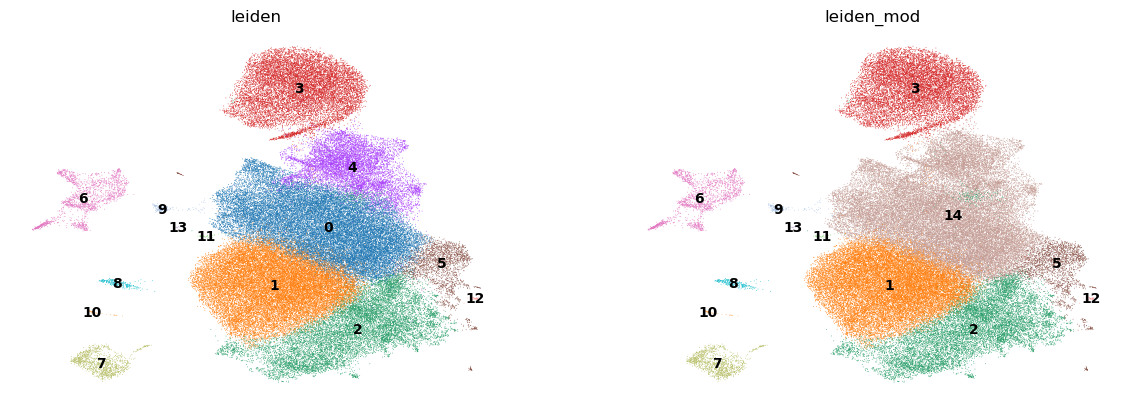

In [59]:
sc.pl.umap(
    ds,
    color=['leiden', 'leiden_mod'],
    frameon=False,
    legend_loc="on data"
)

#### Merge Differentiating Keratinocytes / Squamous

5, 11, 12, 13 -> 15

In [60]:
new_c = '15'
if new_c not in ds.obs['leiden_mod'].cat.categories:
    ds.obs['leiden_mod'] = ds.obs['leiden_mod'].cat.add_categories(new_c)
    
ds.obs.loc[ds.obs['leiden'] == '5', 'leiden_mod'] = new_c
ds.obs.loc[ds.obs['leiden'] == '11', 'leiden_mod'] = new_c
ds.obs.loc[ds.obs['leiden'] == '12', 'leiden_mod'] = new_c
ds.obs.loc[ds.obs['leiden'] == '13', 'leiden_mod'] = new_c

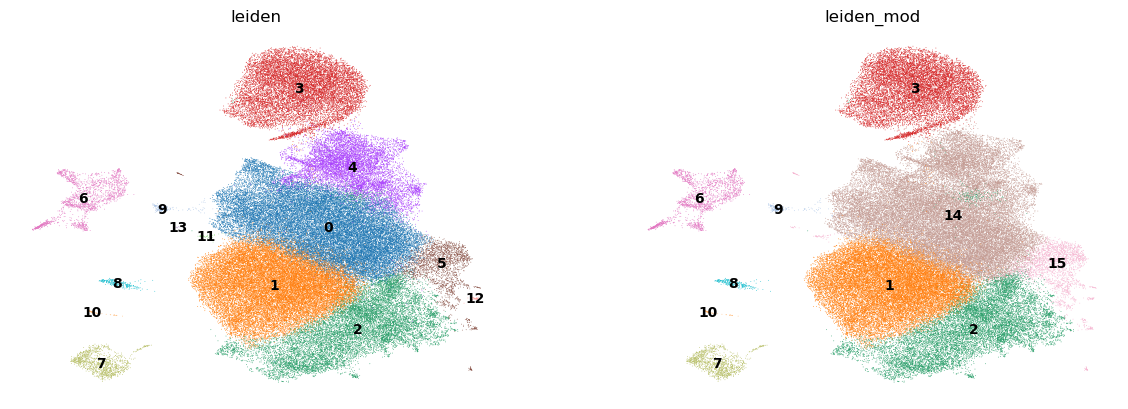

In [61]:
sc.pl.umap(
    ds,
    color=['leiden', 'leiden_mod'],
    frameon=False,
    legend_loc="on data"
)

### Subcluster

In [62]:
ds_subc = {}
m_subc = {}

#### Cluster 6 - resolve myeloid cells

In [63]:
subc_idx = '6'
ds_subc[subc_idx] = ds[ds.obs['leiden_mod'] == subc_idx].copy()

sc.tl.leiden(ds_subc[subc_idx], key_added='subcluster', resolution=0.2)
ds_subc[subc_idx].obs['subcluster'] = ds_subc[subc_idx].obs['subcluster'].cat.rename_categories({c: subc_idx+'-'+c for c in ds_subc[subc_idx].obs['subcluster'].cat.categories})

# normalize, log-transform, and get markers
sc.pp.normalize_total(ds_subc[subc_idx], target_sum=1e4)
sc.pp.log1p(ds_subc[subc_idx])
sc.tl.rank_genes_groups(ds_subc[subc_idx], 'subcluster', method='wilcoxon', n_genes=200, use_raw=False)
#m_subc[subc_idx] = sc_utils.get_markers(ds_subc[subc_idx], 'subcluster')
m_subc[subc_idx] = get_markers(ds_subc[subc_idx], 'subcluster')

/tmp/ipykernel_1707634/1454545344.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ds_subc[subc_idx], key_added='subcluster', resolution=0.2)


In [64]:
temp_m_subc = m_subc[subc_idx]

for clust in temp_m_subc['cluster'].unique():
    print(clust)
    print(temp_m_subc[temp_m_subc['cluster'] == clust][['avg_logFC', 'pct.1', 'pct.2', 'cluster', 'gene']].sort_values(['cluster', 'pct.1'], ascending=False))
    print('\n')

6-0
    avg_logFC     pct.1     pct.2 cluster        gene
0    2.454048  0.995461  0.910267     6-0         FTL
12   0.745900  0.993949  0.981018     6-0        FTH1
6    2.908201  0.984871  0.673857     6-0       IFI30
18   1.697328  0.894100  0.665229     6-0      TYROBP
21   1.952434  0.813918  0.532355     6-0         LYZ
16   1.973786  0.801815  0.491803     6-0      FCER1G
38   1.078740  0.774584  0.581536     6-0     S100A10
9    2.313347  0.723147  0.398619     6-0      LGALS1
4    3.230186  0.706505  0.296808     6-0      LGALS3
26   1.328233  0.658094  0.447800     6-0        AIF1
24   1.434469  0.638427  0.425367     6-0       TIMP1
2    3.944687  0.577912  0.126833     6-0        ACP5
1    9.185192  0.561271  0.005177     6-0        C1QC
7    2.936827  0.549168  0.211389     6-0       FABP5
25   1.414554  0.537065  0.327006     6-0      MS4A6A
14   2.491719  0.534039  0.210526     6-0       TGFBI
17   1.928636  0.527988  0.264884     6-0        CSTB
3    7.746420  0.468986 

6-0: TYROBP, LYZ, FCER1G, S100A10, LGALS1, LGALS3, C1QA - macrophages?

6-1: HLA-DQA1, COTL1, HLA-DQA2... FCER1A - dendritic marker? CD207 - langerhans cells are in there? Are these dendritic cells? cDC2?? (CST3, COTL1, LYZ, DMXL2(-), CLEC10A, FCER1A)

6-2: FCN1, S100A9, S100A8 - Monocytes?

6-3: GZMB, JCHAIN, ALOX5AP, IGKC - pDC?

6-4: CD52, MS4A1, CD79A, CD37, LTB, ID3 - B-cells?

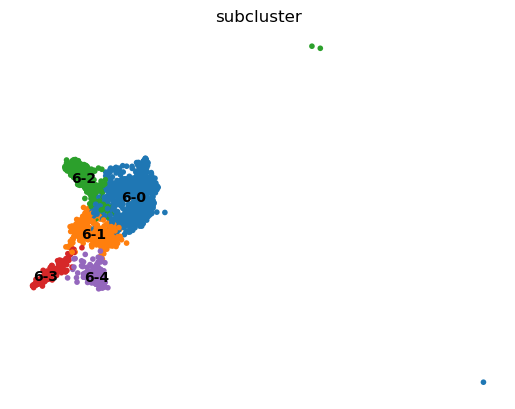

In [65]:
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'],
    frameon=False,
    legend_loc="on data"
)

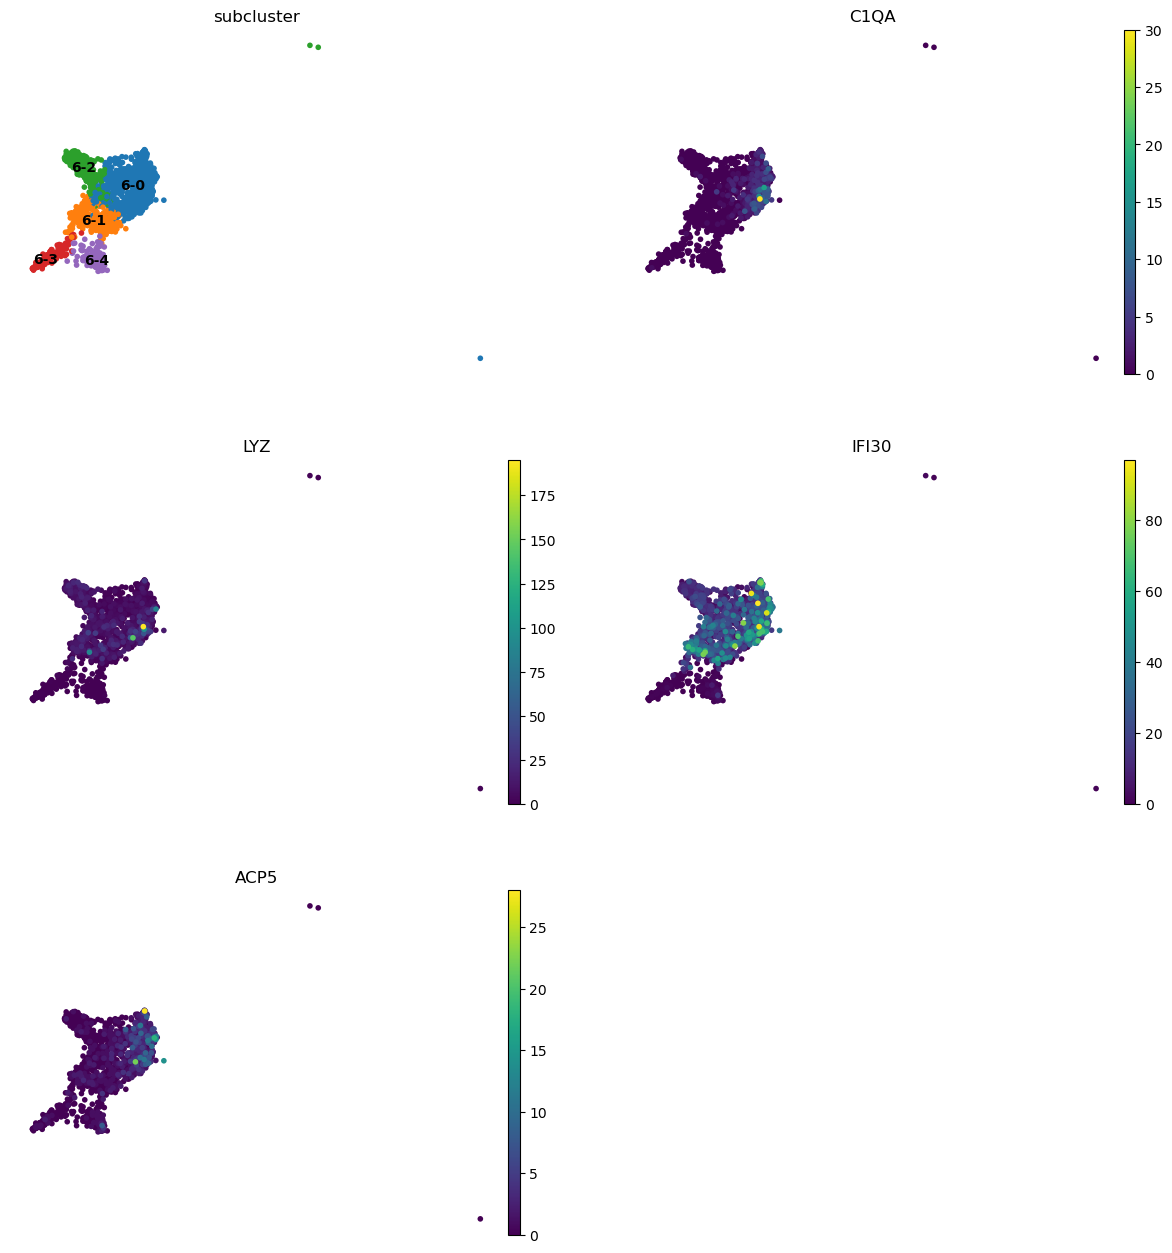

In [66]:
genes = ['C1QA', 'LYZ', 'IFI30', 'ACP5']
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

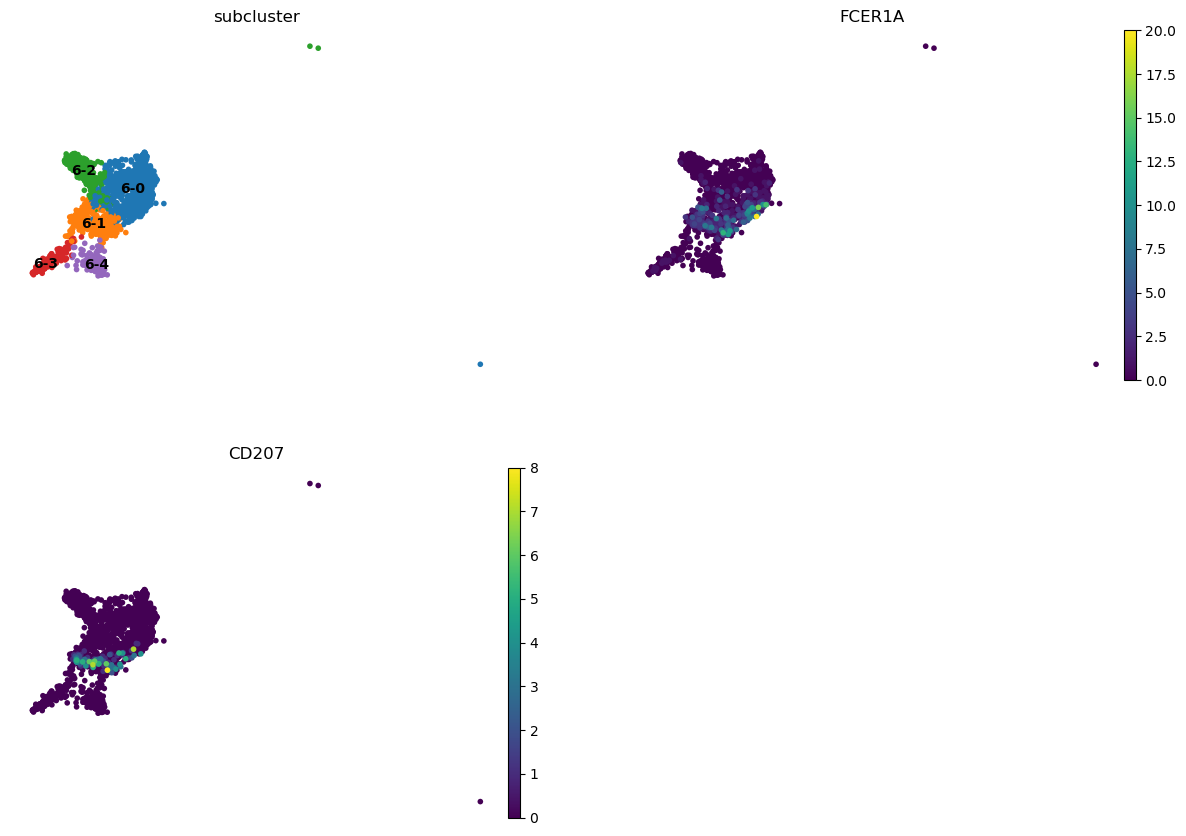

In [67]:
genes = ['FCER1A', 'CD207', ]
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

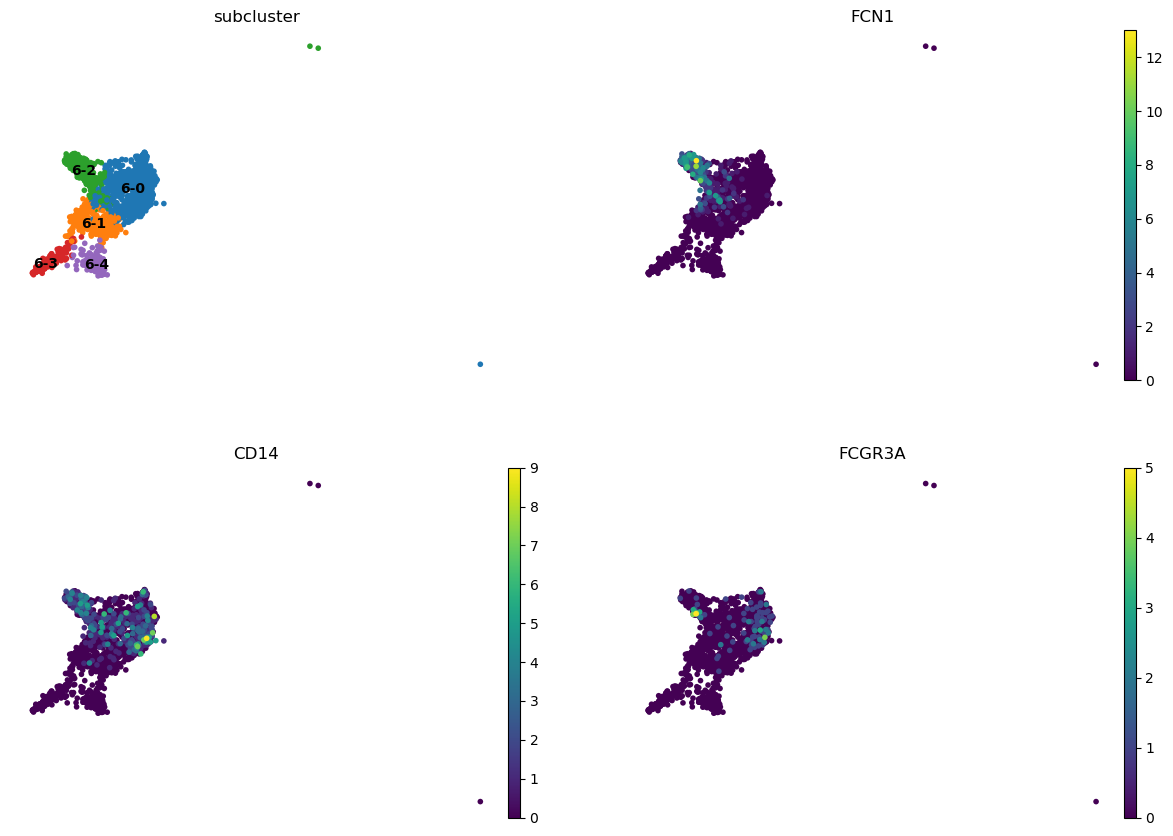

In [68]:
genes = ['FCN1', 'CD14', 'FCGR3A']
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

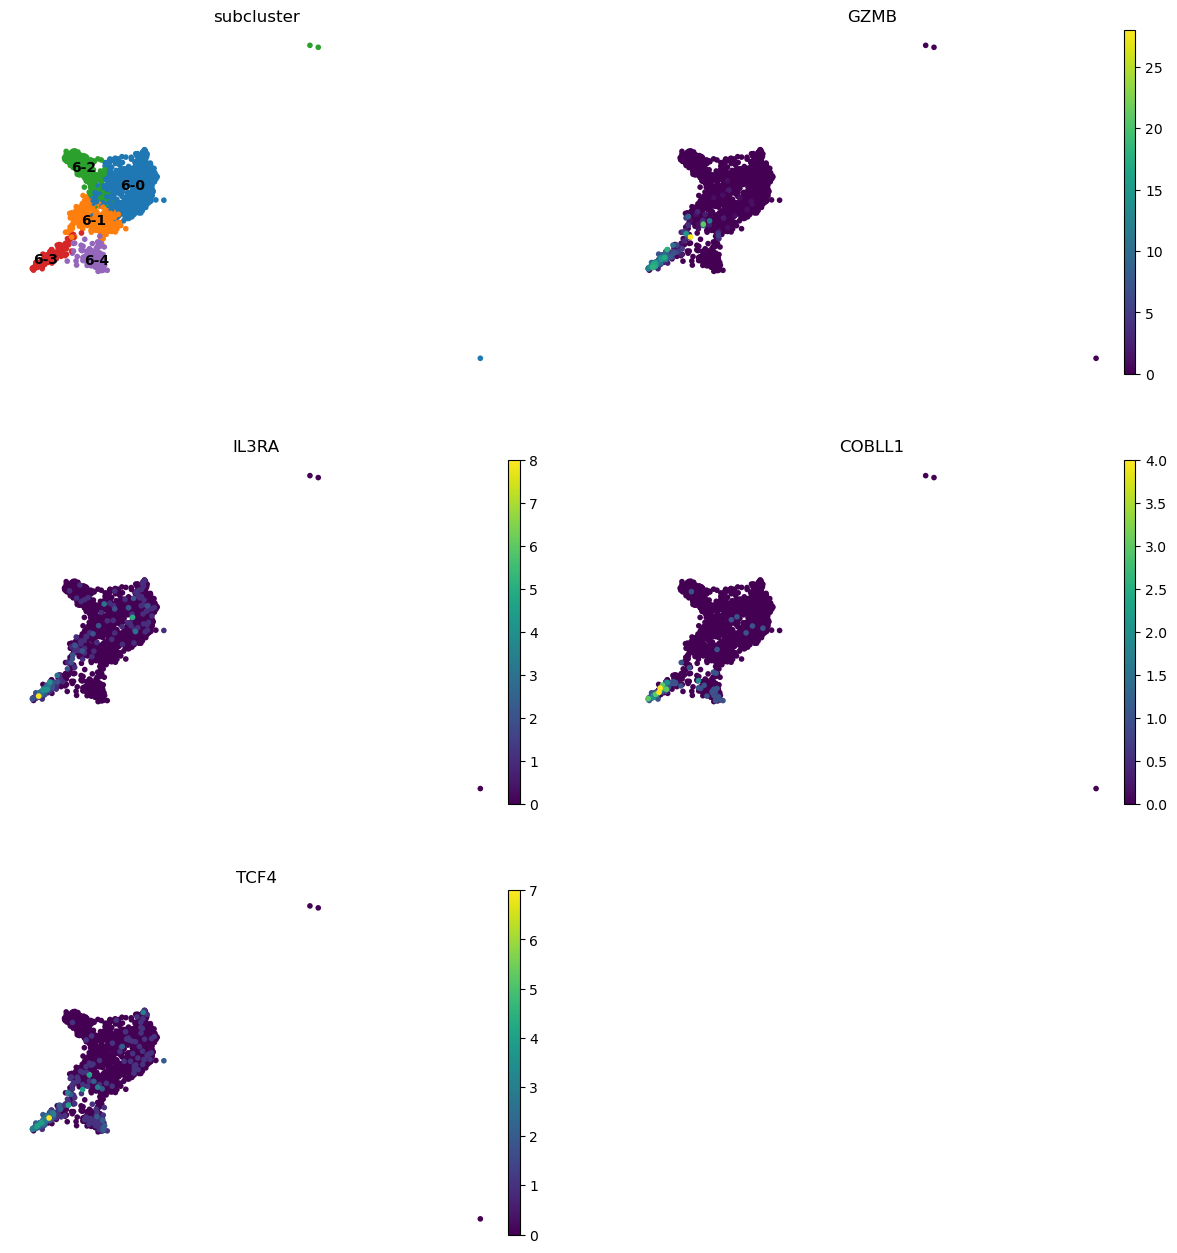

In [69]:
genes = ["GZMB", "IL3RA", "COBLL1", "TCF4"]
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

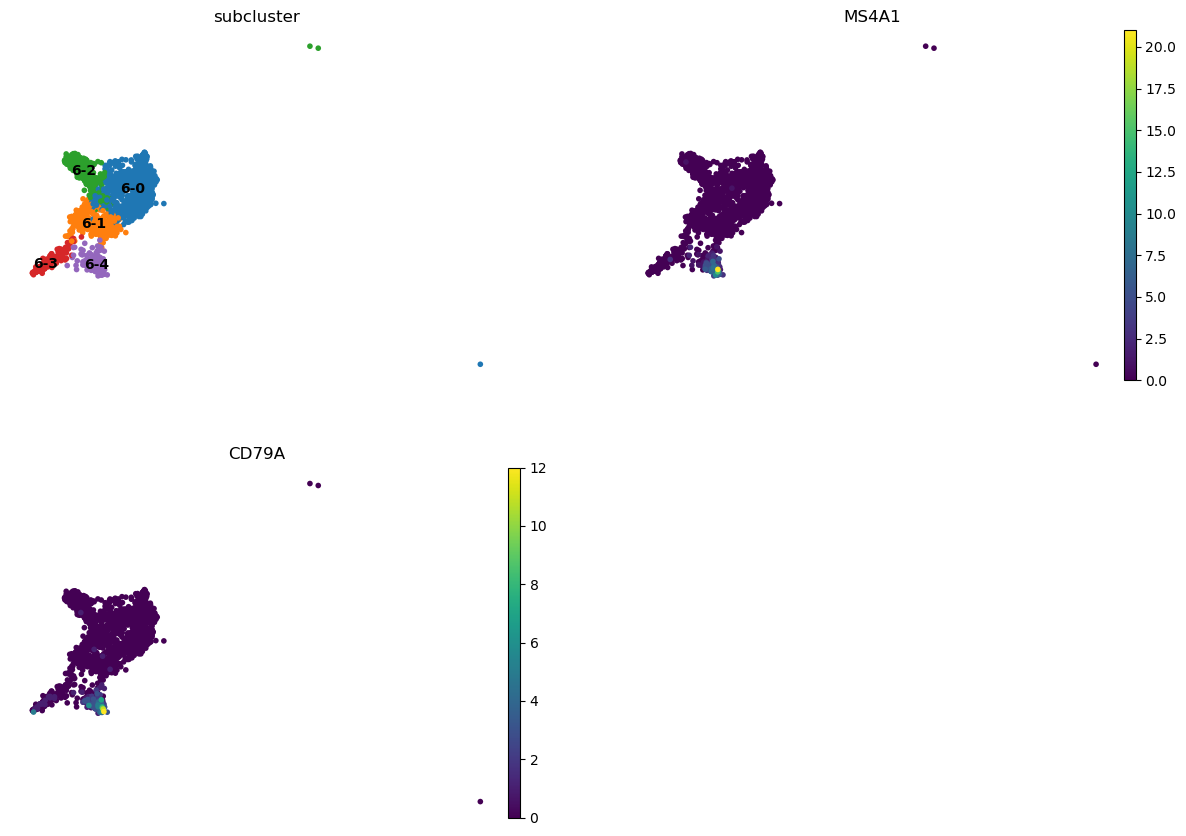

In [70]:
genes = ["MS4A1", "CD79A"]
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

##### Conclusions
- 6-0 - Macrophages
- 6-1 - Dendritic cells
- 6-2 - Monocytes
- 6-3 - pDC
- 6-4 - B-cells

### Cluster 7 - T-cells/NK cells?

In [71]:
subc_idx = '7'
ds_subc[subc_idx] = ds[ds.obs['leiden_mod'] == subc_idx].copy()

sc.tl.leiden(ds_subc[subc_idx], key_added='subcluster', resolution=0.2)
ds_subc[subc_idx].obs['subcluster'] = ds_subc[subc_idx].obs['subcluster'].cat.rename_categories({c: subc_idx+'-'+c for c in ds_subc[subc_idx].obs['subcluster'].cat.categories})

# normalize, log-transform, and get markers
sc.pp.normalize_total(ds_subc[subc_idx], target_sum=1e4)
sc.pp.log1p(ds_subc[subc_idx])
sc.tl.rank_genes_groups(ds_subc[subc_idx], 'subcluster', method='wilcoxon', n_genes=200, use_raw=False)
#m_subc[subc_idx] = sc_utils.get_markers(ds_subc[subc_idx], 'subcluster')
m_subc[subc_idx] = get_markers(ds_subc[subc_idx], 'subcluster')

In [72]:
with pd.option_context('display.max_rows', None):
    display(m_subc[subc_idx].sort_values(['cluster', 'pct.1'], ascending=False))

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
400,1.281510e-24,11.460904,1.000000,0.231449,1.281510e-24,7-2,HBB
401,2.631117e-02,2.991863,0.463415,0.096290,2.631117e-02,7-2,KRT19
200,4.106915e-33,1.276458,0.981557,0.929927,4.106915e-33,7-1,RPS12
201,3.848672e-19,1.219536,0.883197,0.804380,3.848672e-19,7-1,FTH1
205,4.732375e-06,0.705364,0.688525,0.654015,4.732375e-06,7-1,FTL
204,4.063292e-08,1.433346,0.545082,0.414599,4.063292e-08,7-1,FXYD5
202,5.128181e-15,3.166648,0.399590,0.132847,5.128181e-15,7-1,LTB
203,3.481914e-11,2.720420,0.377049,0.143066,3.481914e-11,7-1,IL7R
206,7.934045e-03,1.417747,0.299180,0.185401,7.934045e-03,7-1,NFKBIA
207,4.719831e-02,5.378544,0.118852,0.004380,4.719831e-02,7-1,TNFRSF4


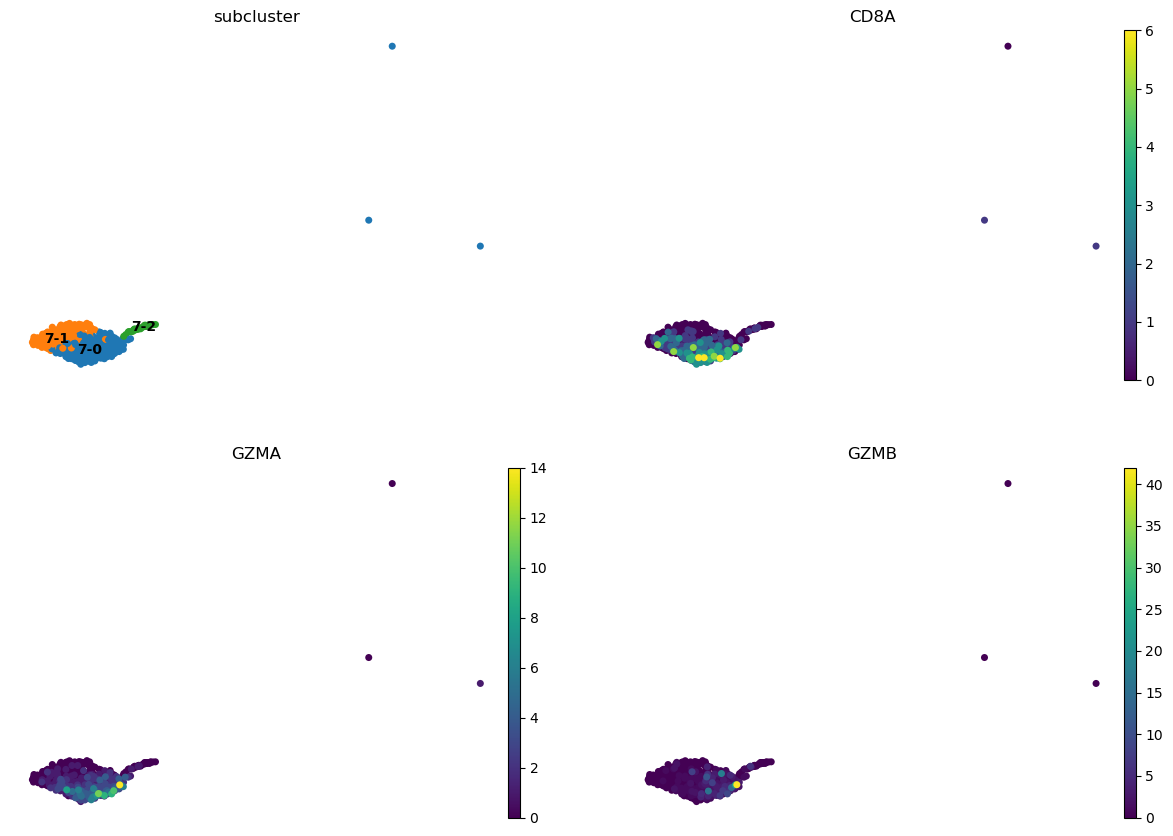

In [73]:
genes = ['CD8A', 'GZMA', 'GZMB']
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

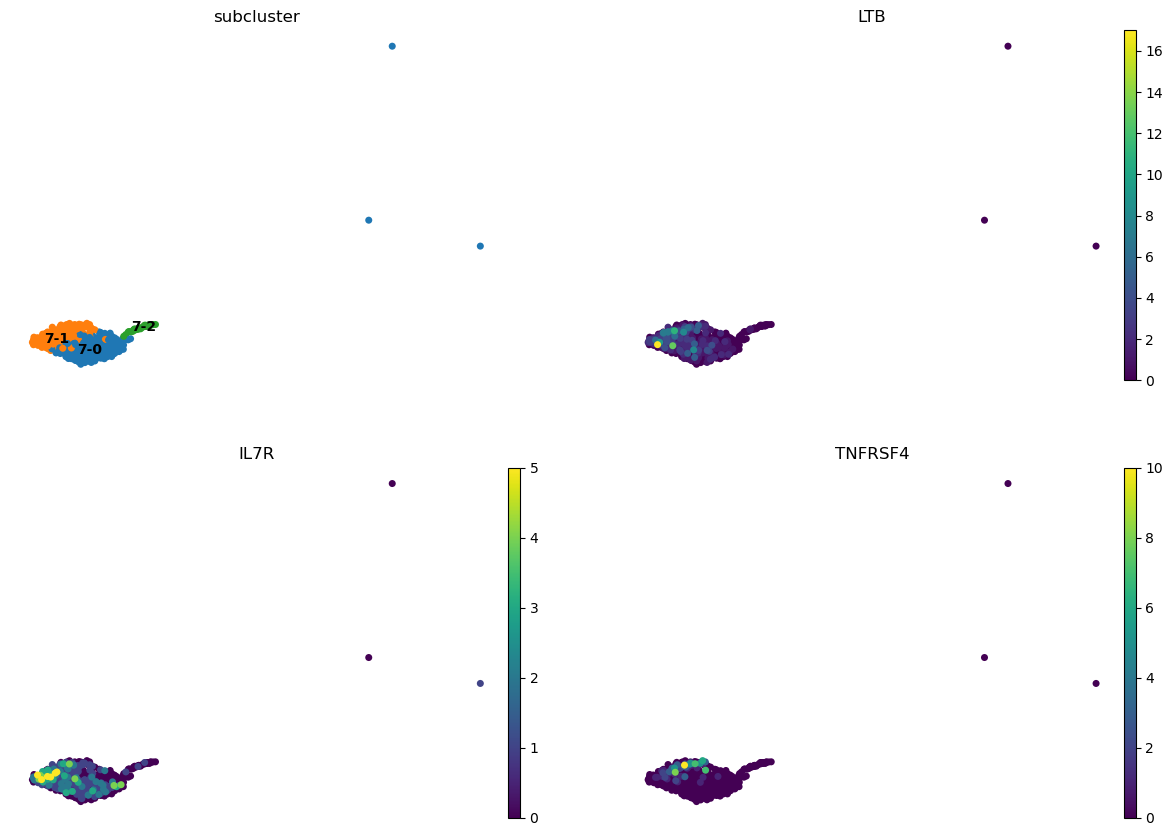

In [74]:
genes = ['LTB', 'IL7R', 'TNFRSF4']
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

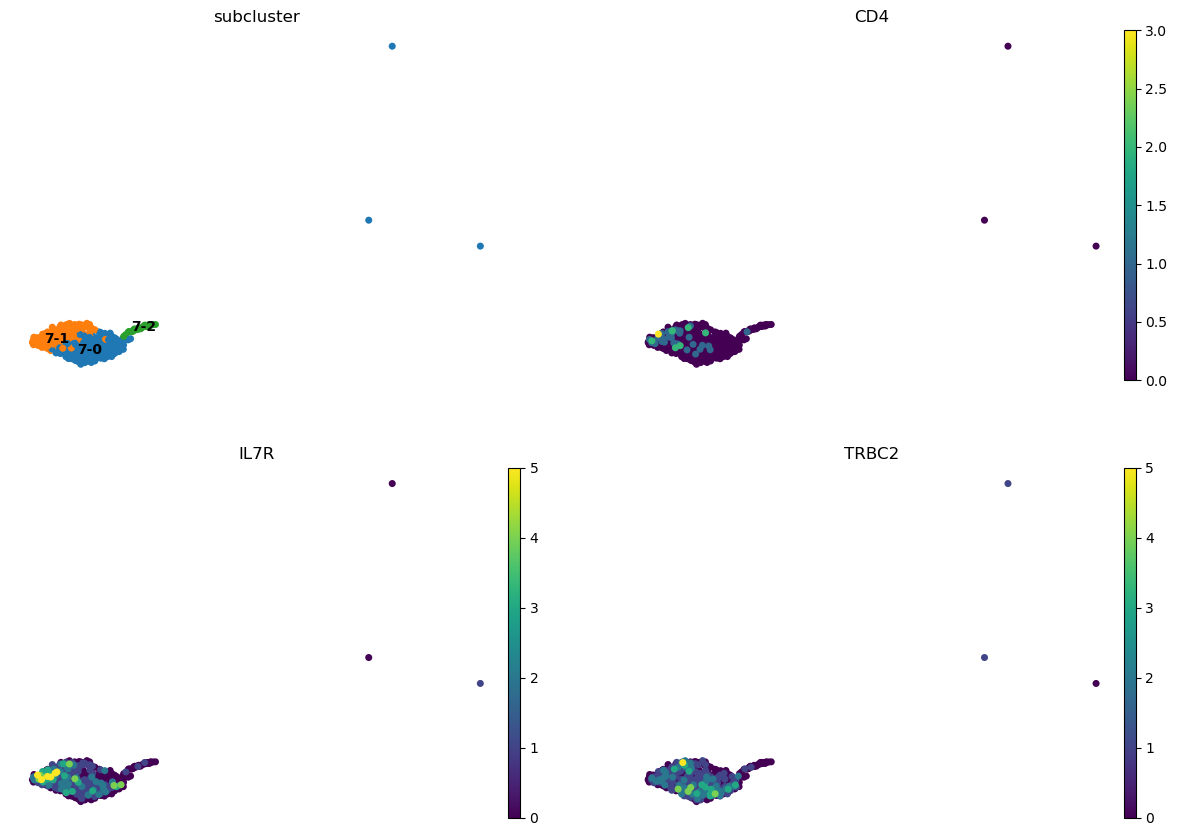

In [75]:
genes = ['CD4', 'IL7R', 'TRBC2']
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

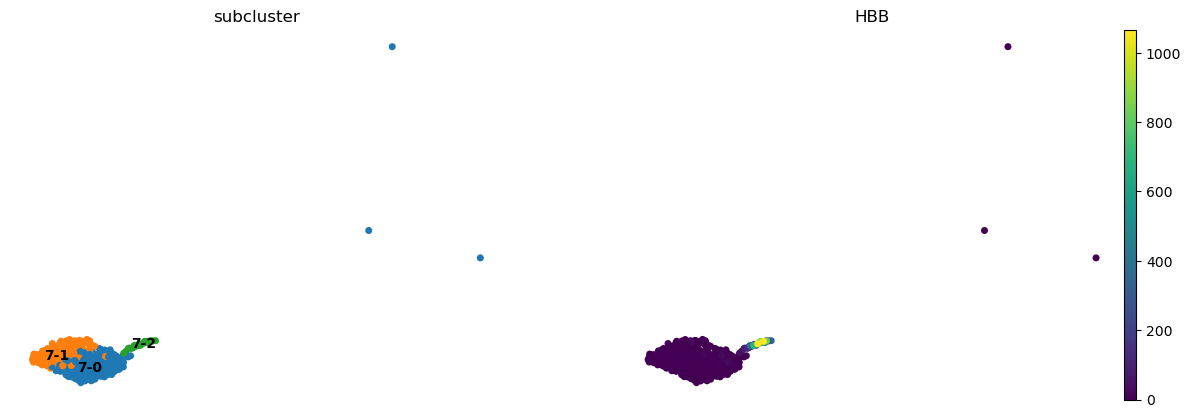

In [76]:
genes = ['HBB']
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'] + genes,
    frameon=False,
    legend_loc="on data",
    ncols=2
)

#### Conclusions
- 7-0 - CD8+ T Cells
- 7-1 - CD4+ T Cells
- 7-2 - HBB (discard)

### Cluster 3 - Ciliated, low quality

In [77]:
subc_idx = '3'
ds_subc[subc_idx] = ds[ds.obs['leiden_mod'] == subc_idx].copy()

sc.tl.leiden(ds_subc[subc_idx], key_added='subcluster', resolution=0.2)
ds_subc[subc_idx].obs['subcluster'] = ds_subc[subc_idx].obs['subcluster'].cat.rename_categories({c: subc_idx+'-'+c for c in ds_subc[subc_idx].obs['subcluster'].cat.categories})

# normalize, log-transform, and get markers
sc.pp.normalize_total(ds_subc[subc_idx], target_sum=1e4)
sc.pp.log1p(ds_subc[subc_idx])
sc.tl.rank_genes_groups(ds_subc[subc_idx], 'subcluster', method='wilcoxon', n_genes=200, use_raw=False)
#m_subc[subc_idx] = sc_utils.get_markers(ds_subc[subc_idx], 'subcluster')
m_subc[subc_idx] = get_markers(ds_subc[subc_idx], 'subcluster')

In [78]:
with pd.option_context('display.max_rows', None):
    display(m_subc[subc_idx].sort_values(['cluster', 'pct.1'], ascending=False))

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
400,1.295701e-79,2.647749,0.738298,0.571106,1.295701e-79,3-2,CDHR3
401,3.633472e-70,2.749247,0.691489,0.503989,3.633472e-70,3-2,CFAP157
402,3.616305e-69,2.792505,0.685106,0.488467,3.616305e-69,3-2,DNAAF1
404,4.363034e-22,1.295866,0.557447,0.521505,4.363034e-22,3-2,HYDIN
403,1.039276e-31,2.031340,0.551064,0.433663,1.039276e-31,3-2,DNAH12
406,3.818594e-13,0.631545,0.551064,0.594606,3.818594e-13,3-2,DNAH5
405,2.010163e-17,1.683095,0.463830,0.370534,2.010163e-17,3-2,DNAH3
407,5.192301e-08,0.980605,0.419149,0.401492,5.192301e-08,3-2,TMEM231
408,1.003903e-06,0.935707,0.404255,0.386576,1.003903e-06,3-2,DNAH9
412,8.259406e-04,1.499050,0.236170,0.161984,8.259406e-04,3-2,CCDC57


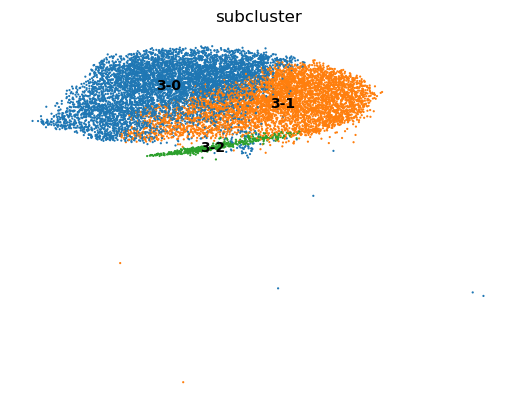

In [79]:
sc.pl.umap(
    ds_subc[subc_idx],
    color=['subcluster'],
    frameon=False,
    legend_loc="on data"
)

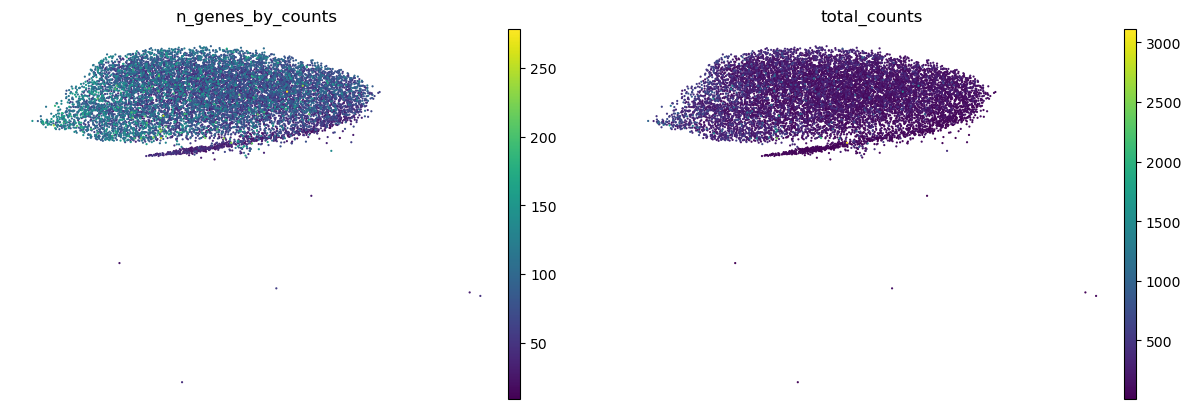

In [80]:
sc.pl.umap(
    ds_subc[subc_idx],
    color=['n_genes_by_counts', 'total_counts'],
    frameon=False,
    legend_loc="on data"
)

#### Conclusions

- Don't seem meaningfully differentiable. 3-2 might be lower quality with low gene number, but I don't know if it's separable enough to justify discarding.

### Subcluster Integration
    
    
-    6-0 - Macrophages
-    6-1 - DC2
-    6-2 - Monocytes
-    6-3 - pDC
-    6-4 - B-cells


-    7-0 - CD8+ T Cells
-    7-1 - CD4+ T Cells
-    7-2 - HBB (discard)



#### Verify Cluster IDs

In [81]:
ds_subc_copy = ds_subc.copy()

subc_list = ['6', '7']
for c in subc_list:
    print(ds_subc_copy[c].obs['subcluster'].cat.categories)

Index(['6-0', '6-1', '6-2', '6-3', '6-4'], dtype='object')
Index(['7-0', '7-1', '7-2'], dtype='object')


In [82]:
ds_sub = ds.copy()

In [83]:
for c in subc_list:
    new_cat = ds_subc_copy[c].obs['subcluster'].cat.categories
    old_cat = ds_sub.obs['leiden_mod'].cat.categories
    unmerged_cat = ds_sub.obs['leiden_unmerged'].cat.categories
    
    ds_sub.obs['leiden_mod'] = ds_sub.obs['leiden_mod'].cat.set_categories(new_cat.append(old_cat))
    ds_sub.obs['leiden_unmerged'] = ds_sub.obs['leiden_unmerged'].cat.set_categories(new_cat.append(unmerged_cat))
    
    ds_subc_copy[c].obs['subcluster'] = ds_subc_copy[c].obs['subcluster'].cat.set_categories(new_cat.append(old_cat))
    ds_subc_copy[c].obs['subcluster_unmerged'] = ds_subc_copy[c].obs['subcluster'].cat.set_categories(new_cat.append(unmerged_cat))
    
    ds_sub.obs.loc[ds_subc_copy[c].obs.index, 'leiden_mod'] = ds_subc_copy[c].obs['subcluster']
    ds_sub.obs.loc[ds_subc_copy[c].obs.index, 'leiden_unmerged'] = ds_subc_copy[c].obs['subcluster_unmerged']

In [84]:
# Drop cluster 7-2
clust_72_idx = (ds_sub.obs['leiden_mod'] == '7-2')
ds_sub = ds_sub[~clust_72_idx]

/home/trc891/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


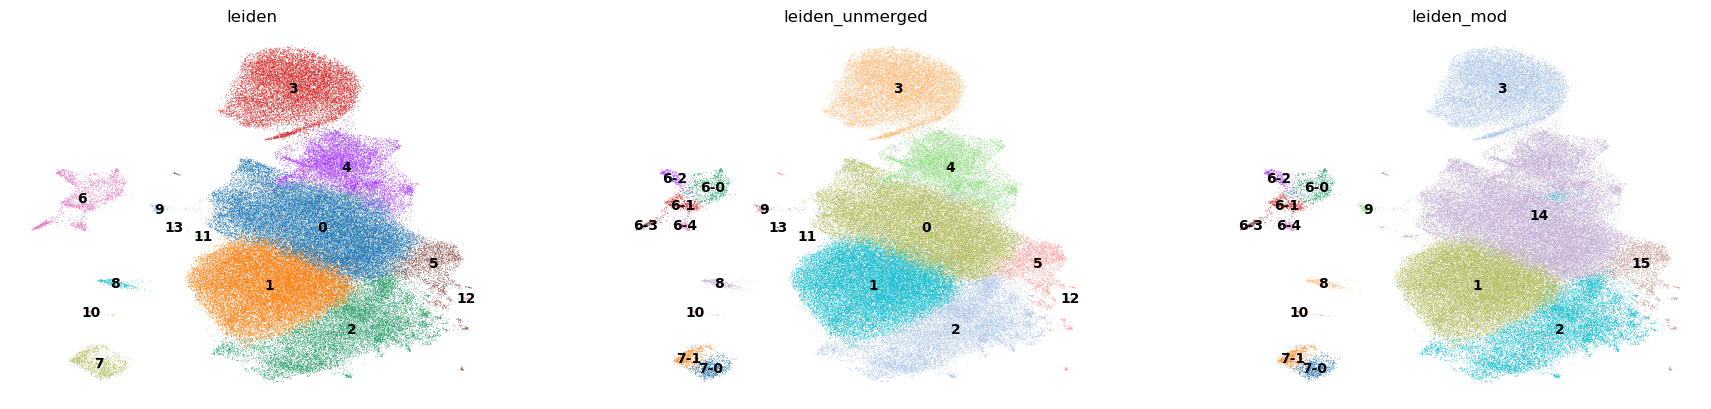

In [85]:
sc.pl.umap(
    ds_sub,
    color=['leiden', 'leiden_unmerged', 'leiden_mod'],
    frameon=False,
    legend_loc="on data"
)

#### Annotate

In [87]:
unmerged_annotations = {'0': 'Secretory-1',
                        '1': 'Suprabasal',
                        '2': 'Basal',
                        '3': 'Multiciliated',
                        '4': 'Secretory-2',
                        '5': 'Squamous-1',
                        '6-0': 'Macrophages',
                        '6-1': 'DC2',
                        '6-2': 'Monocytes',
                        '6-3': 'pDCs',
                        '6-4': 'B-cells',
                        '7-0': 'CD8+ T-cells',
                        '7-1': 'CD4+ T-cells',
                        '8': 'Ionocytes',
                        '9': 'Mast',
                        '10': 'Stromal',
                        '11': 'Squamous-2',
                        '12': 'Squamous-3',
                        '13': 'Squamous-4'
                       }
                        

annotations = {'1': 'Suprabasal',
               '2': 'Basal',
               '3': 'Multiciliated',
               '6-0': 'Macrophages',
               '6-1': 'DC2',
               '6-2': 'Monocytes',
               '6-3': 'pDCs',
               '6-4': 'B-cells',
               '7-0': 'CD8+ T-cells',
               '7-1': 'CD4+ T-cells',
               '8': 'Ionocytes',
               '9': 'Mast',
               '10': 'Stromal',
               '14': 'Secretory',
               '15': 'Squamous'
              }

In [88]:
ds_sub.obs['leiden_final'] = ds_sub.obs['leiden_mod'].copy()
ds_sub.obs['cell_type_annot'] = [annotations[c] for c in ds_sub.obs['leiden_final']]
ds_sub.obs['cell_type_annot_unmerged'] = [unmerged_annotations[c] for c in ds_sub.obs['leiden_unmerged']]

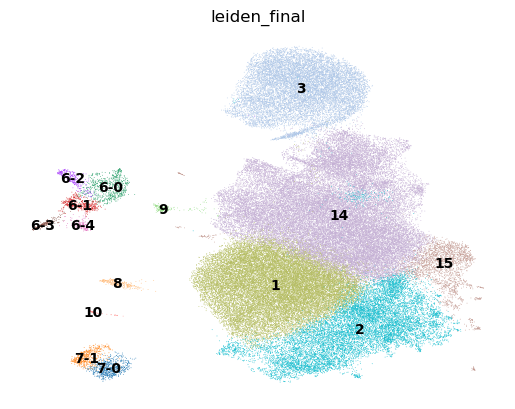

In [89]:
sc.pl.umap(
    ds_sub,
    color=['leiden_final'],
    frameon=False,
    legend_loc="on data",
)

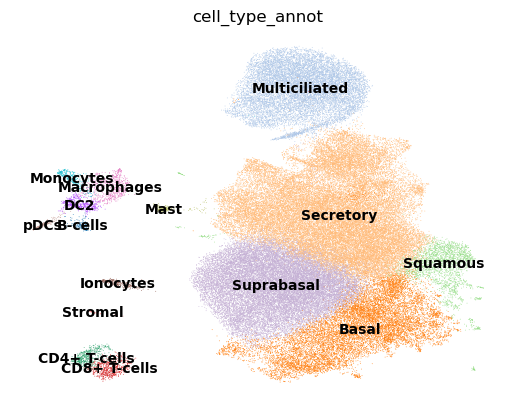

In [90]:
sc.pl.umap(
    ds_sub,
    color=['cell_type_annot'],
    frameon=False,
    legend_loc="on data",
)

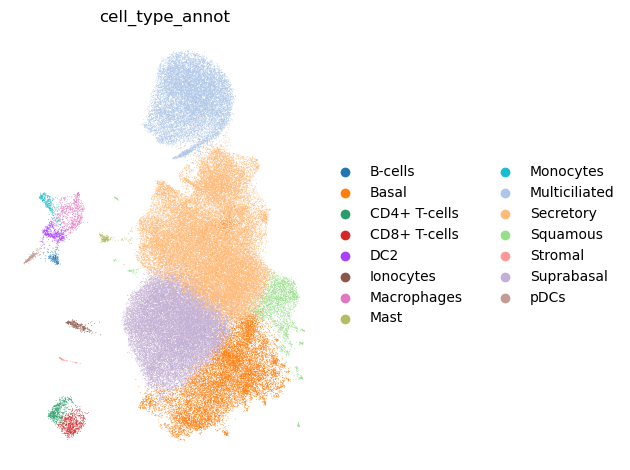

In [91]:
sc.pl.umap(
    ds_sub,
    color=['cell_type_annot'],
    frameon=False,
    show=False
)

plt.tight_layout()
plt.savefig('{}/fig5/fig5a.png'.format(OUT_DIR))

In [92]:
ds_sub

AnnData object with n_obs × n_vars = 89601 × 1000
    obs: 'orig.ident', 'Doublet score', 'Library ID', 'Chemistry', 'GEX library Index', 'Step 1 date YYYY/MM/DD', 'Project', 'Class', 'Sample', 'Cell viabiliy', 'Age', 'Sex', 'Race', 'OnModulator', 'Modulator', 'Include', 'Comments', 'n_genes', 'batch', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'leiden_mod', 'leiden_unmerged', 'leiden_final', 'cell_type_annot', 'cell_type_annot_unmerged'
    var: 'gene_ids-0', 'feature_types-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells-10', 'gene_ids-11', 'feature_types-11', 'n_cells-11', 'gene_ids-12', 'feature_types-12', 'n_cells-12', 'gene_ids-13', 'feature_types-13', 'n_cells-13', 'gene_ids-14', 'feature_types-14', 'n_cells-14', 'gene_ids-15', 'feature_types-15', 'n

### Generate Meta/Markers, Save Output

In [93]:
# put sub-clustered clusters in 'leiden' field for cellbrowser
ds_sub.obs['leiden_orig'] = ds_sub.obs['leiden']
ds_sub.obs['leiden'] = ds_sub.obs['leiden_mod']

ds_sub.obs['leiden_mod'] = ds_sub.obs['leiden_mod'].cat.remove_unused_categories()
ds_sub.obs['leiden_mod'].cat.categories

Index(['7-0', '7-1', '6-0', '6-1', '6-2', '6-3', '6-4', '1', '2', '3', '8',
       '9', '10', '14', '15'],
      dtype='object')

In [94]:
ds_sub.write(f'{OUT_DIR}/sc_files/00scvi{OUT_SUFFIX}.h5ad')

In [95]:
sc.pp.normalize_total(ds_sub, target_sum=1e4)
sc.pp.log1p(ds_sub)

sc.tl.rank_genes_groups(ds_sub, 'leiden_mod', method='wilcoxon', n_genes=200, use_raw=False)
m_all = get_markers(ds_sub, 'leiden_mod')

In [96]:
with pd.option_context('display.max_rows', None):
    display(m_all.sort_values(['cluster', 'pct.1'], ascending=False))

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
2220,1.346900e-31,1.317706,1.000000,0.950662,1.346900e-31,9,FTH1
2215,1.678396e-45,2.159461,0.981651,0.827674,1.678396e-45,9,FTL
2227,4.219593e-19,1.485456,0.954128,0.835237,4.219593e-19,9,RPS12
2200,1.315386e-112,9.759743,0.912844,0.055603,1.315386e-112,9,VIM
2201,4.927453e-107,16.268904,0.871560,0.001454,4.927453e-107,9,TPSAB1
2202,3.594942e-96,15.814218,0.825688,0.000794,3.594942e-96,9,TPSB2
2203,4.589970e-92,16.818613,0.807339,0.000246,4.589970e-92,9,CPA3
2204,7.139181e-74,8.498193,0.738532,0.021111,7.139181e-74,9,SRGN
2206,1.810676e-70,8.104343,0.724771,0.022577,1.810676e-70,9,LAPTM5
2205,1.208645e-71,15.837779,0.711009,0.000179,1.208645e-71,9,GATA2


In [97]:
m_all.to_csv(f'{OUT_DIR}/sc_files/00scvi{OUT_SUFFIX}-markers.csv')
ds_sub.obs.to_csv(f'{OUT_DIR}/sc_files/00scvi{OUT_SUFFIX}-metadata.csv')

## Visualize Marker Genes

Let's generate a set of marker genes (2-3 per cluster) that demonstrate why we annotated the way we did.

annotations = {'1': 'Suprabasal',
               '2': 'Basal',
               '3': 'Multiciliated',
               '6-0': 'Macrophages',
               '6-1': 'Dendritic cells',
               '6-2': 'Monocytes',
               '6-3': 'pDCs',
               '6-4': 'B-cells',
               '7-0': 'CD8+ T-cells',
               '7-1': 'CD4+ T-cells',
               '8': 'Ionocytes',
               '9': 'Mast',
               '10': 'Stromal',
               '14': 'Secretory',
               '15': 'Keratinocytes',
               '16': 'Stratified squamous'
              }

In [98]:
gene_dict = {'Suprabasal': ['KRT10', 'FABP5'],
             'Basal': ['KRT5', 'DLK2'],
             'Secretory': ['SCGB1A1', 'MUC5AC'],
             'Multiciliated': ['FOXJ1', 'PIFO', 'CAPS', 'C20orf85'],
             'Macrophages': ['TYROBP', 'C1QA', 'APOC1'],
             'DC2': ['HLA-DPB1', 'FCER1A', 'CD207'],
             'Monocytes': ['FCN1', 'FCER1G', 'CD14'],
             'pDCs': ['GZMB', 'JCHAIN', 'IL3RA'],
             'B-cells': ['MS4A1', 'CD79A'],
             'CD8+ T-cells': ['CD8A', 'CCL5', 'IL32'],
             'CD4+ T-cells': ['CD4', 'IL7R'],
             'Ionocytes': ['CFTR', 'FOXI1', 'STAP1'],
             'Mast': ['TPSAB1', 'TPSB2', 'MS4A2'],
             'Stromal': ['COL1A1', 'MMP2'],
             'Secretory': ['SCGB1A1', 'MUC5AC', 'BPIFB1', 'BPIFA1'],
             'Squamous': ['SPRR3', 'KRT2', 'KRT6A'],
            }

/home/trc891/.local/lib/python3.10/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 1000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/tmp/ipykernel_1707634/2575297523.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


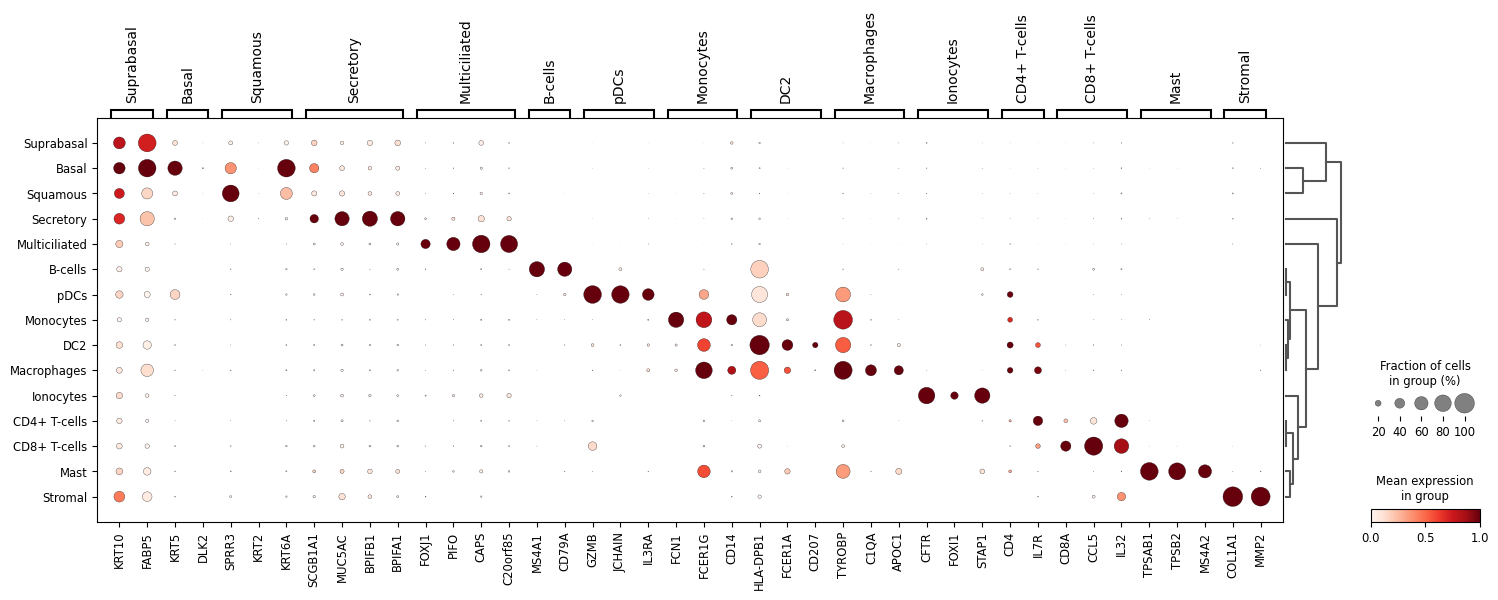

In [99]:
sc.pl.dotplot(ds_sub, gene_dict, groupby='cell_type_annot',
              dendrogram=True, swap_axes=False, standard_scale='var',
              show=False
             )

plt.tight_layout()
plt.savefig('{}/fig5/fig5b.png'.format(OUT_DIR))

## Abundance and differential abundance

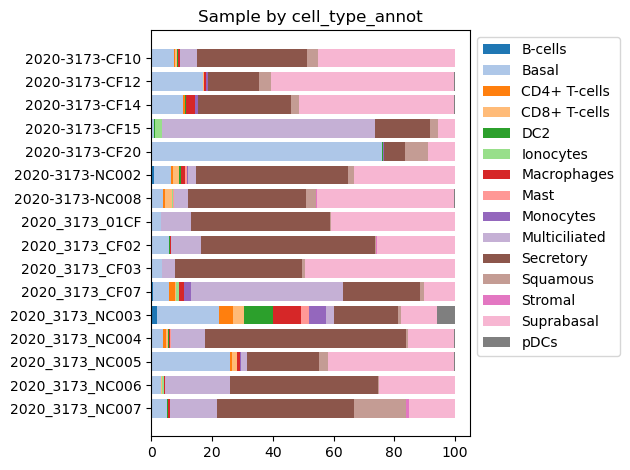

In [100]:
ax = sc_utils.plot_composition(
    ds_sub,
    group_by='Sample',
    color='cell_type_annot',
    relative=True,
    #plot_numbers=True
)
ax.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5/fig5c.png')
plt.show()

In [101]:
ds_sub

AnnData object with n_obs × n_vars = 89601 × 1000
    obs: 'orig.ident', 'Doublet score', 'Library ID', 'Chemistry', 'GEX library Index', 'Step 1 date YYYY/MM/DD', 'Project', 'Class', 'Sample', 'Cell viabiliy', 'Age', 'Sex', 'Race', 'OnModulator', 'Modulator', 'Include', 'Comments', 'n_genes', 'batch', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'leiden_mod', 'leiden_unmerged', 'leiden_final', 'cell_type_annot', 'cell_type_annot_unmerged', 'leiden_orig'
    var: 'gene_ids-0', 'feature_types-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells-1', 'gene_ids-10', 'feature_types-10', 'n_cells-10', 'gene_ids-11', 'feature_types-11', 'n_cells-11', 'gene_ids-12', 'feature_types-12', 'n_cells-12', 'gene_ids-13', 'feature_types-13', 'n_cells-13', 'gene_ids-14', 'feature_types-14', 'n_cells-14', 'gene_ids-15', 'featur

In [102]:
batch_name = 'Sample'

# get counts for each sample, then pick a random column. Rename the column
ct_ds = ds_sub.obs.groupby(['cell_type_annot', 'Class', batch_name], observed=True).count().Chemistry.reset_index()
ct_ds = ct_ds.rename(columns={'Chemistry': 'n_cells'})

# get total cell counts for each cluster
cluster_ct = ct_ds.groupby('cell_type_annot', observed=True).sum(numeric_only=True)
# get total cell counts for each subject
subj_ct = ct_ds.groupby(batch_name, observed=True).sum(numeric_only=True)

In [103]:
ct_ds['total_subj'] = 0
for i in subj_ct.itertuples(name=None):
    ct_ds.loc[ct_ds[batch_name] == i[0], 'total_subj'] = i[1]
    
ct_ds['cell_proportion_subj'] = ct_ds['n_cells'] / ct_ds['total_subj']

In [104]:
ct_ds

,cell_type_annot,Class,Sample,n_cells,total_subj,cell_proportion_subj
0,B-cells,CF,2020-3173-CF12,1,2316,0.000432
1,B-cells,CF,2020-3173-CF14,1,721,0.001387
2,B-cells,CF,2020_3173_CF02,2,10493,0.000191
3,B-cells,CF,2020_3173_CF07,19,3233,0.005877
4,B-cells,NC,2020-3173-NC002,45,5053,0.008906
5,B-cells,NC,2020-3173-NC008,10,7737,0.001292
6,B-cells,NC,2020_3173_NC003,60,3205,0.018721
7,B-cells,NC,2020_3173_NC004,18,12241,0.001470
8,B-cells,NC,2020_3173_NC005,11,6434,0.001710
9,B-cells,NC,2020_3173_NC006,2,8780,0.000228


In [105]:
stat_results_subj = []
for clust in ct_ds['cell_type_annot'].unique():
    try:
        # for each subject, get proportion of cells that are within each cluster
        ctrl = ct_ds['cell_proportion_subj'][(ct_ds['cell_type_annot'] == clust) & (ct_ds['Class'] == 'NC')]
        cf = ct_ds['cell_proportion_subj'][(ct_ds['cell_type_annot'] == clust) & (ct_ds['Class'] == 'CF')]
        pval = scipy.stats.mannwhitneyu(ctrl, cf).pvalue

        stat_results_subj.append(["cell_type_annot", clust, "NC", "CF", ctrl.size, cf.size, pval])
    except ValueError:
        stat_results_subj.append(["cell_type_annot", clust, "NC", "CF", ctrl.size, cf.size, np.nan])

stat_results_subj = pd.DataFrame(stat_results_subj,
                               columns = ['var', 'val', 'group1', 'group2',
                                          'g1_size', 'g2_size', 'pval']
                                    )

no_nan_filter = stat_results_subj['pval'].notnull()
stat_results_subj['pval_adj'] = [np.nan] * len(no_nan_filter)
stat_results_subj.loc[no_nan_filter, 'pval_adj'] = statsmodels.stats.multitest.fdrcorrection(stat_results_subj[no_nan_filter].pval, alpha=0.01)[1]

In [106]:
stat_results_subj

,var,val,group1,group2,g1_size,g2_size,pval,pval_adj
0,cell_type_annot,B-cells,NC,CF,7,4,0.527273,1.000000
1,cell_type_annot,Basal,NC,CF,7,9,1.000000,1.000000
2,cell_type_annot,CD4+ T-cells,NC,CF,6,8,0.081252,0.406260
3,cell_type_annot,CD8+ T-cells,NC,CF,7,7,0.037879,0.285714
4,cell_type_annot,DC2,NC,CF,7,8,0.778866,1.000000
5,cell_type_annot,Ionocytes,NC,CF,5,5,0.690476,1.000000
6,cell_type_annot,Macrophages,NC,CF,7,8,0.866511,1.000000
7,cell_type_annot,Mast,NC,CF,6,4,0.038095,0.285714
8,cell_type_annot,Monocytes,NC,CF,5,8,1.000000,1.000000
9,cell_type_annot,Multiciliated,NC,CF,7,7,0.620047,1.000000


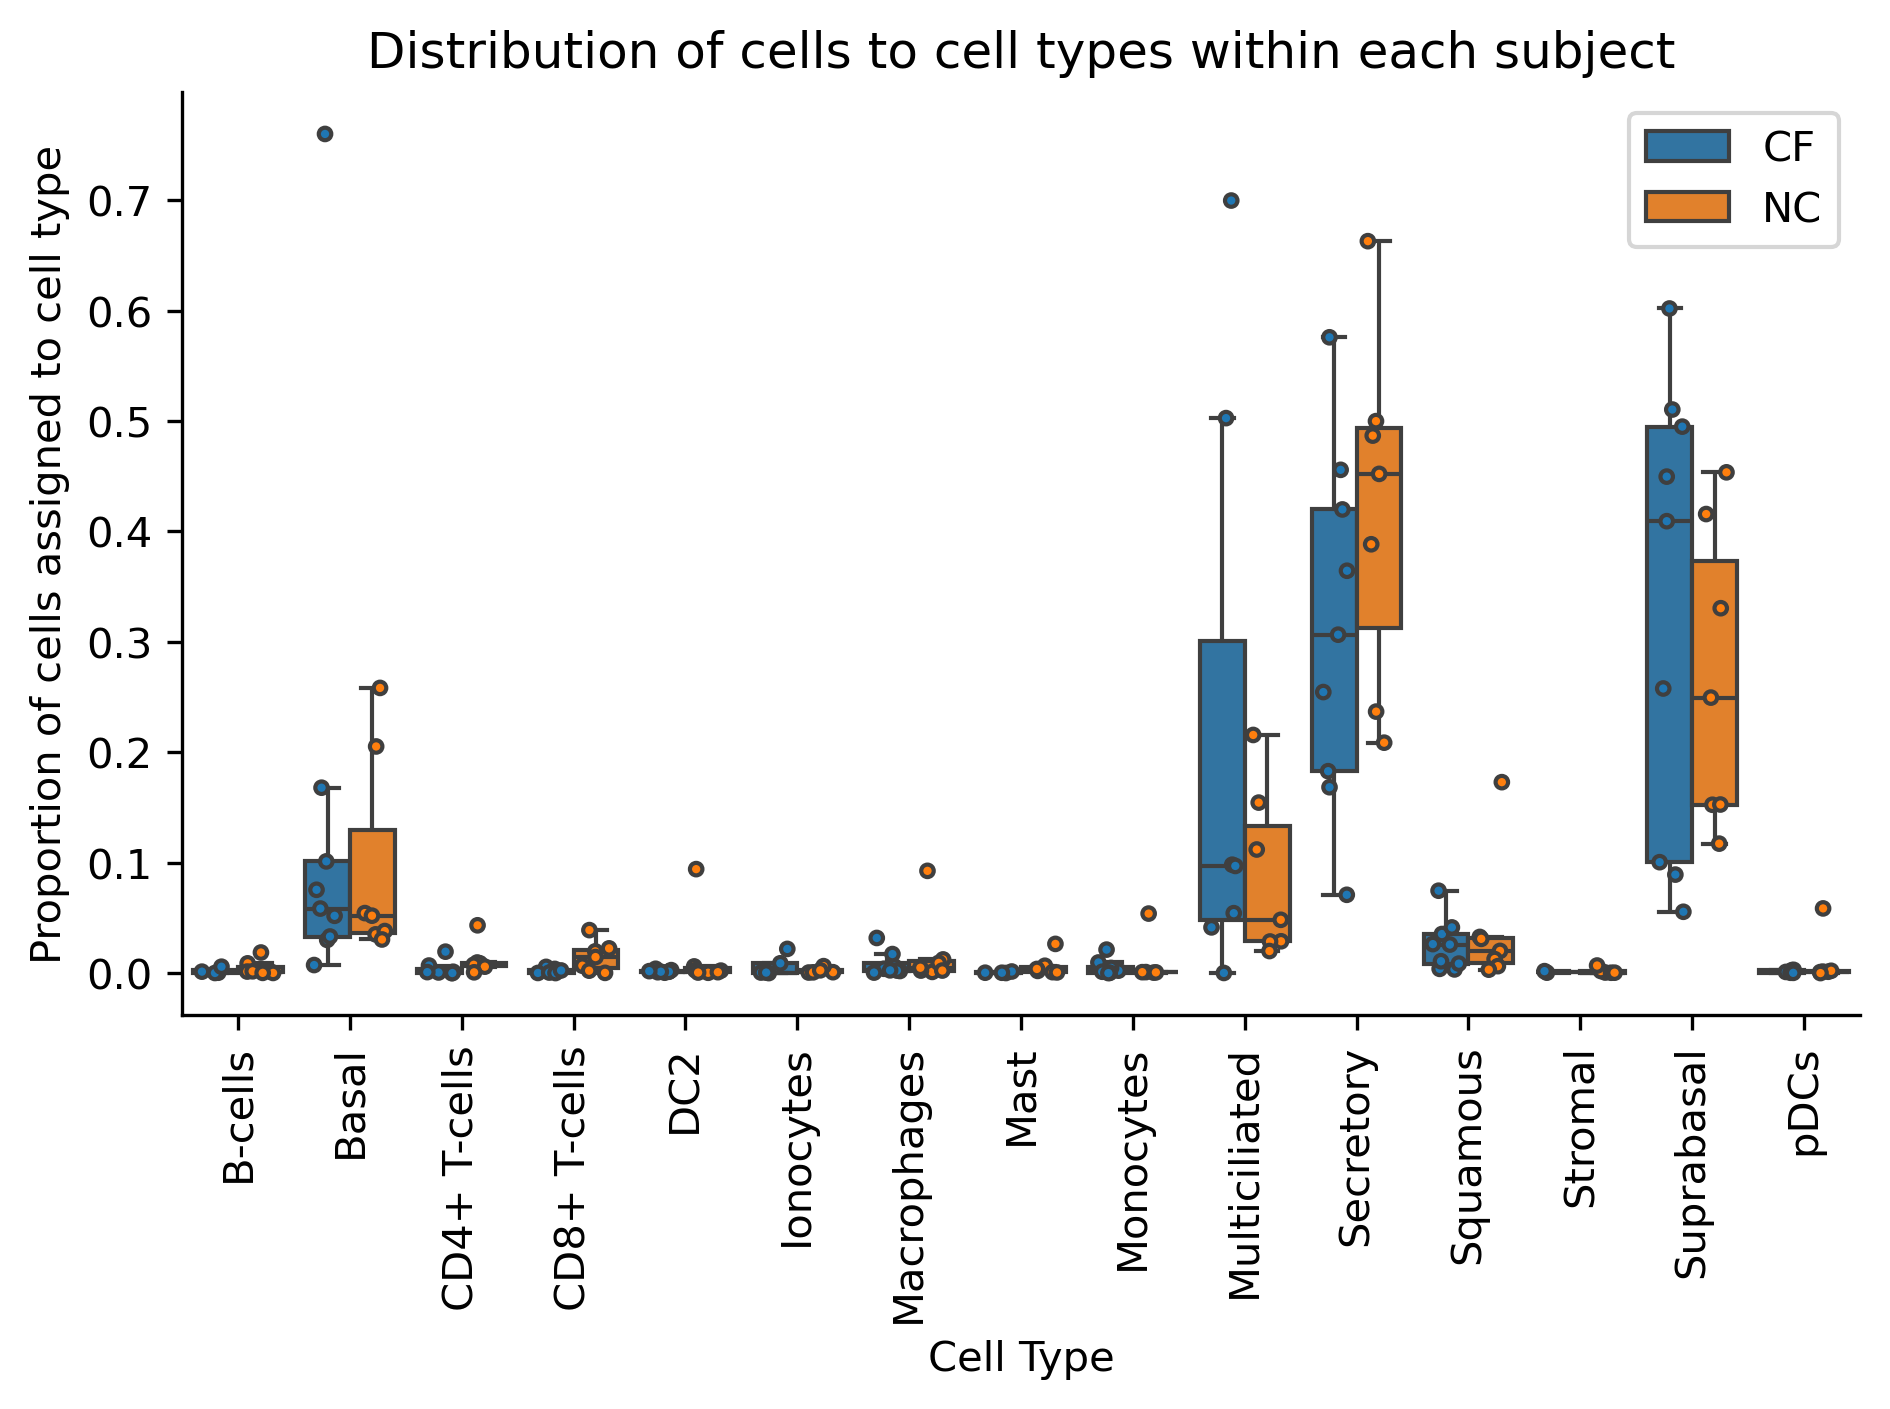

In [107]:
fig, ax = plt.subplots(dpi=300)
#sns.set(style='white')

plt.title('Distribution of cells to cell types within each subject')

sns.boxplot(x='cell_type_annot', y='cell_proportion_subj', data=ct_ds, hue='Class', showfliers=False)
sns.stripplot(x='cell_type_annot', y='cell_proportion_subj', data=ct_ds, hue='Class', size=3, jitter=0.25, dodge=True,
              linewidth=1)

ax.set_ylabel('Proportion of cells assigned to cell type')
plt.xticks(rotation='vertical')
ax.set_xlabel('Cell Type')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/fig5/fig5d.png')
plt.show()

## Descriptive statistics

In [108]:
ct_ds

,cell_type_annot,Class,Sample,n_cells,total_subj,cell_proportion_subj
0,B-cells,CF,2020-3173-CF12,1,2316,0.000432
1,B-cells,CF,2020-3173-CF14,1,721,0.001387
2,B-cells,CF,2020_3173_CF02,2,10493,0.000191
3,B-cells,CF,2020_3173_CF07,19,3233,0.005877
4,B-cells,NC,2020-3173-NC002,45,5053,0.008906
5,B-cells,NC,2020-3173-NC008,10,7737,0.001292
6,B-cells,NC,2020_3173_NC003,60,3205,0.018721
7,B-cells,NC,2020_3173_NC004,18,12241,0.001470
8,B-cells,NC,2020_3173_NC005,11,6434,0.001710
9,B-cells,NC,2020_3173_NC006,2,8780,0.000228


In [109]:
ct_ds.groupby(['cell_type_annot', 'Class']).mean(numeric_only=True)

/tmp/ipykernel_1707634/2947410271.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_ds.groupby(['cell_type_annot', 'Class']).mean(numeric_only=True)


n_cells   total_subj  cell_proportion_subj
cell_type_annot Class                                                
B-cells         CF        5.750000  4190.750000              0.001972
                NC       21.000000  6701.000000              0.004659
Basal           CF      965.777778  4743.777778              0.142874
                NC      540.285714  6701.000000              0.096277
CD4+ T-cells    CF       11.375000  5145.875000              0.004056
                NC       66.166667  7241.666667              0.012712
CD8+ T-cells    CF        6.714286  5778.000000              0.002116
                NC       85.285714  6701.000000              0.015034
DC2             CF        5.875000  4414.875000              0.001777
                NC       56.285714  6701.000000              0.015324
Ionocytes       CF       33.800000  5789.000000              0.006432
                NC       17.000000  7453.600000              0.002250
Macrophages     CF       20.625000  5145.875000              0.008344
                NC       70.857143  6701.000000              0.017900
Mast            CF        6.000000  8287.250000              0.000633
                NC       32.333333  7241.666667              0.006796
Monocytes       CF       12.500000  4414.875000              0.005032
                NC       39.400000  6934.000000              0.011430
Multiciliated   CF     1066.000000  5665.285714              0.213381
                NC      648.571429  6701.000000              0.086882
Secretory       CF     1519.222222  4743.777778              0.311036
                NC     3096.428571  6701.000000              0.419381
Squamous        CF      129.111111  4743.777778              0.025638
                NC      185.857143  6701.000000              0.039919
Stromal         CF        5.500000  6863.000000              0.001166
                NC       10.200000  7453.600000              0.002068
Suprabasal      CF     1223.555556  4743.777778              0.329931
                NC     1830.857143  6701.000000              0.267415
pDCs            CF        3.200000  3702.200000              0.001526
                NC       39.166667  7241.666667              0.010778

In [110]:
ct_ds.groupby(['cell_type_annot', 'Class']).std(numeric_only=True)

/tmp/ipykernel_1707634/3192443277.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_ds.groupby(['cell_type_annot', 'Class']).std(numeric_only=True)


n_cells   total_subj  cell_proportion_subj
cell_type_annot Class                                                
B-cells         CF        8.845903  4327.797467              0.002654
                NC       22.686266  3204.681003              0.006888
Basal           CF     2262.999104  3626.490824              0.236151
                NC      520.219413  3204.681003              0.094240
CD4+ T-cells    CF       21.016575  3656.117552              0.006628
                NC       46.572166  3141.414437              0.015349
CD8+ T-cells    CF        3.903600  3444.652280              0.002092
                NC       59.317547  3204.681003              0.013547
DC2             CF        4.356850  3730.621145              0.001136
                NC      109.071405  3204.681003              0.034849
Ionocytes       CF       57.233731  3449.640489              0.009453
                NC       22.011361  3409.345362              0.002445
Macrophages     CF       16.387604  3656.117552              0.010888
                NC      101.886258  3204.681003              0.033226
Mast            CF        6.782330  1941.225107              0.000607
                NC       30.480595  3141.414437              0.009919
Monocytes       CF       23.058931  3730.621145              0.007339
                NC       74.708099  3409.642943              0.023786
Multiciliated   CF     1529.699535  3586.790613              0.272997
                NC      706.377580  3204.681003              0.075825
Secretory       CF     1896.102303  3626.490824              0.159440
                NC     2503.756834  3204.681003              0.158125
Squamous        CF      213.777597  3626.490824              0.022980
                NC      199.696794  3204.681003              0.059769
Stromal         CF        0.707107  5133.595231              0.000975
                NC        9.093954  3409.345362              0.002798
Suprabasal      CF     1180.347312  3626.490824              0.207782
                NC     1118.009456  3204.681003              0.135295
pDCs            CF        2.387467  3903.943993              0.001297
                NC       73.128426  3141.414437              0.023466